In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [30]:
comment = "#"
# df=pd.read_csv('data.csv', on_bad_lines='skip')
df = pd.read_csv("data.csv", comment="#")
print(df) 


         pl_name   hostname  default_flag  sy_snum  sy_pnum  discoverymethod  \
0        7 CMa c      7 CMa             1        1        2  Radial Velocity   
1        7 CMa c      7 CMa             0        1        2  Radial Velocity   
2       DMPP-1 b     DMPP-1             1        1        4  Radial Velocity   
3       DMPP-1 c     DMPP-1             1        1        4  Radial Velocity   
4       DMPP-1 d     DMPP-1             1        1        4  Radial Velocity   
..           ...        ...           ...      ...      ...              ...   
562    bet Pic c    bet Pic             1        1        2  Radial Velocity   
563    bet Pic c    bet Pic             0        1        2  Radial Velocity   
564    bet Pic c    bet Pic             0        1        2  Radial Velocity   
565  eps Ind A b  eps Ind A             0        3        1  Radial Velocity   
566  eps Ind A b  eps Ind A             1        3        1  Radial Velocity   

     disc_year           disc_facility 

In [ ]:
#data set is 567x92, there are 92 columns and 567 rows
#Column titles include sy_snum, hostname, default flag, sypnum, and discovery method

In [31]:
#Planet name is the name of the exoplanet
#Host name is the host star name
#discovery method is the means by which the planet was found.
#Spectral type is the emision spectral type. 
#Equilibrium Temperature is the energy balnce between absorbed and radiated energy. 
#Planet mass is the mass of the planet. 
print(type(df))
df = pd.DataFrame(df)
cols = ["pl_name", "hostname", "discoverymethod", "st_spectype", "pl_eqt", "pl_bmassj"]
small_df = df[cols]

print(small_df.head())

<class 'pandas.core.frame.DataFrame'>
    pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
0   7 CMa c    7 CMa  Radial Velocity         NaN     NaN   0.870000
1   7 CMa c    7 CMa  Radial Velocity         NaN     NaN   0.912000
2  DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
3  DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
4  DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540


In [44]:
small_df.shape
#now 567x6
small_df1=small_df.dropna()
# print(small_df1.head())
# small_df1.shape
# #now 67x6, g7 rows, six columns
# print(small_df1.tail())
# print (cols)
small_df1.value_counts("discoverymethod")

discoverymethod
Transit            52
Radial Velocity    13
Imaging             2
Name: count, dtype: int64

In [ ]:
# discoverymethod
# Transit            52
# Radial Velocity    13
# Imaging             2
# Transit has the most, it occours when planet moves infront of host star, doppler effect is measure in raidal velocity,imaging is direct photography

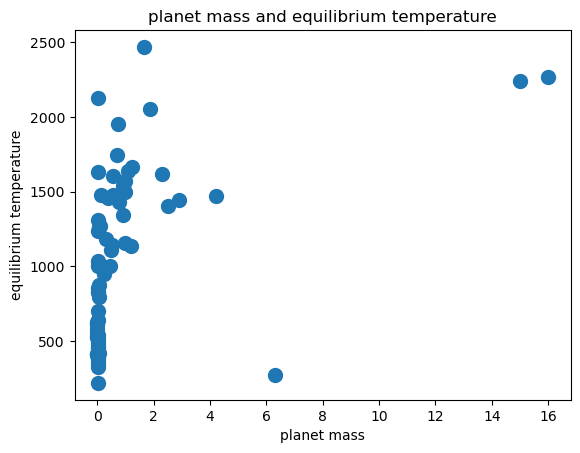

In [52]:
small_df1.plot(x='pl_bmassj', y='pl_eqt', kind='scatter',s=100)
plt.title('planet mass and equilibrium temperature')
plt.xlabel('planet mass')
plt.ylabel('equilibrium temperature')
plt.show()

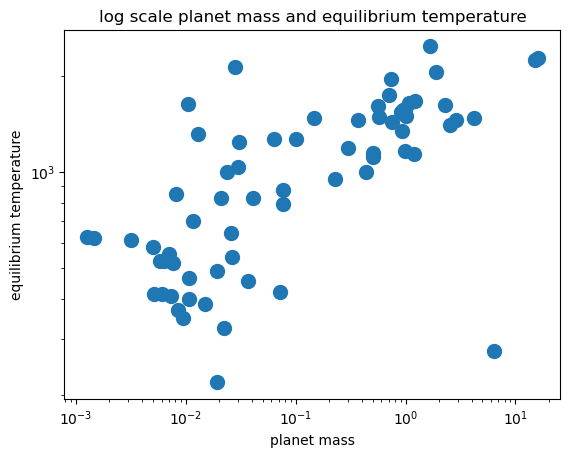

In [57]:
# log_mass = np.log("pl_bmassj")
# log_temperature = np.log("pl_eqt")
# small_df1.plot(x='log_mass', y='log_temperature', kind='scatter',s=100)
small_df1.plot(x='pl_bmassj', y='pl_eqt', kind='scatter',s=100)
plt.xscale('log')
plt.yscale('log')
plt.title('log scale planet mass and equilibrium temperature')
plt.xlabel('planet mass')
plt.ylabel('equilibrium temperature')
plt.show()

In [58]:
#Most likley small.
print(small_df1)

         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
2       DMPP-1 b     DMPP-1  Radial Velocity        F8 V   877.0   0.076362
3       DMPP-1 c     DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
4       DMPP-1 d     DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
5       DMPP-1 e     DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
6       DMPP-2 b     DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
..           ...        ...              ...         ...     ...        ...
546   WASP-185 b   WASP-185          Transit        G0 V  1160.0   0.980000
549   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0   1.000000
555   WASP-192 b   WASP-192          Transit        G0 V  1620.0   2.300000
561       XO-7 b       XO-7          Transit        G0 V  1743.0   0.709000
566  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0   6.310000

[67 rows x 6 columns]


In [70]:
coldest_planet = small_df1.idxmin()
print(coldest_planet) 

pl_name              2
hostname             2
discoverymethod    481
st_spectype        521
pl_eqt              68
pl_bmassj          320
dtype: int64


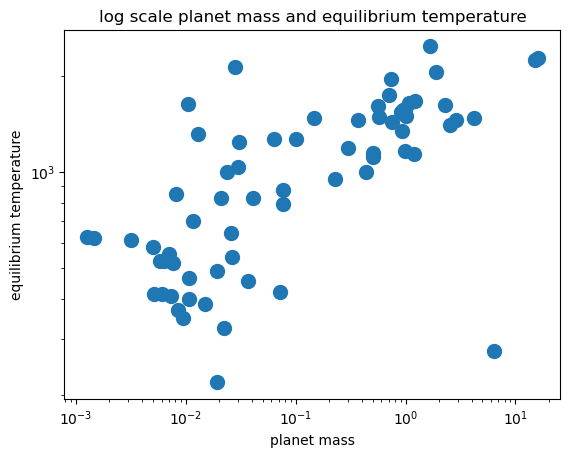

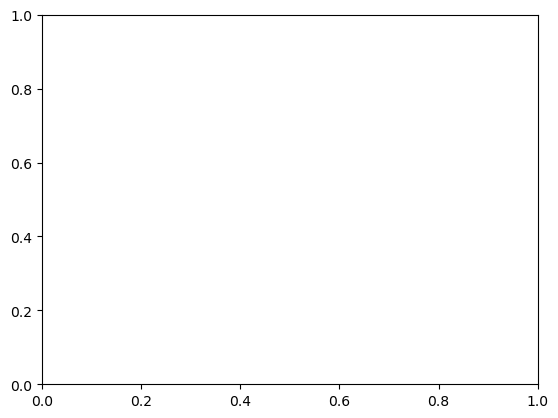

In [79]:
# pl_name              2
# hostname             2
# discoverymethod    481
# st_spectype        521
# pl_eqt              68
# pl_bmassj          320
# dtype: int64
# log_mass = np.log("pl_bmassj")
# log_temperature = np.log("pl_eqt")
# small_df1.plot(x='log_mass', y='log_temperature', kind='scatter',s=100)
small_df1.plot(x='pl_bmassj', y='pl_eqt', kind='scatter',s=100)
plt.xscale('log')
plt.yscale('log')
plt.title('log scale planet mass and equilibrium temperature')
plt.xlabel('planet mass')
plt.ylabel('equilibrium temperature')
plt.show()
for idx, row in small_df1.iterrows():
    plt.annotate([coldest_planet], (row['pl_bmassj'], row['pl_eqt']))


In [81]:
# What is the title of this paper?
# • Summarize the abstract to the best of your ability in your own words.
# there are 25 imaged exoplanets with an outlier being the planet that is large yet very cold. 
# • Does your answer match the exoplanet
#Yes, in bottom right corner of graph
# • What is special about the planet you found?
# It is very large and cold. 
# • Do the mass and equilibrium temperature match what the paper reported? If not, what
# are the differences?
# relativley close to paper report